## Задание

Создайте автокодировщик, удаляющий черные квадраты в случайных областях изображений.

Алгоритм действий:
1. Возьмите базу картинок Mnist.
2. На картинках в случайных местах сделайте чёрные квадраты размера 8 на 8.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения из "зашумленных" квадратом изображений.
4. Добейтесь MSE < 0.0070 на тестовой выборке

## Импорт библиотек

In [ ]:
# Отображение
import matplotlib.pyplot as plt

# Для работы с тензорами
import numpy as np

# Класс создания модели
from tensorflow.keras.models import Model

# Для загрузки данных
from tensorflow.keras.datasets import mnist

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Оптимизатор
from tensorflow.keras.optimizers import Adam

## Загрузка данных

In [ ]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Нормировка данных

In [ ]:
# Нормировка данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [ ]:
# Изменение формы под удобную для Keras
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

## Добавление черных квадратов

X_train_noisy: (60000, 28, 28, 1)
X_test_noisy: (10000, 28, 28, 1)


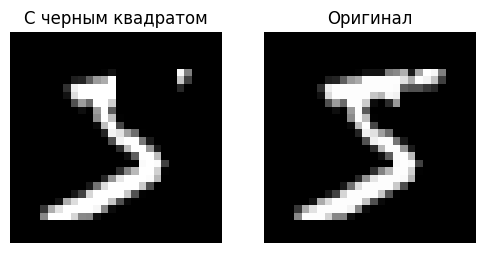

In [ ]:
def add_black_squares(images, square_size=8):
    images_noisy = images.copy()
    for i in range(len(images)):
        x = np.random.randint(0, 28 - square_size)
        y = np.random.randint(0, 28 - square_size)
        images_noisy[i, x:x+square_size, y:y+square_size, 0] = 0
    return images_noisy

X_train_noisy = add_black_squares(X_train)
X_test_noisy = add_black_squares(X_test)

print(f"X_train_noisy: {X_train_noisy.shape}")
print(f"X_test_noisy: {X_test_noisy.shape}")

# Превращаем в плоские векторы
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)
X_train_noisy_flat = X_train_noisy.reshape(-1, 784)
X_test_noisy_flat = X_test_noisy.reshape(-1, 784)

# Визуализация примера
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(X_train_noisy[0].squeeze(), cmap='gray')
plt.title('С черным квадратом')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_train[0].squeeze(), cmap='gray')
plt.title('Оригинал')
plt.axis('off')
plt.show()

## Создание модели

In [ ]:
from tensorflow.keras.layers import Dense

inp = Input(shape=(784,))

x = Dense(256, activation='relu')(inp)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(256, activation='relu')(x)
out = Dense(784, activation='sigmoid')(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [ ]:
history = autoencoder.fit(
    X_train_noisy_flat, X_train_flat,
    validation_data=(X_test_noisy_flat, X_test_flat),
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0590 - val_loss: 0.0353
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0293 - val_loss: 0.0255
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0236 - val_loss: 0.0216
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0207 - val_loss: 0.0196
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0191 - val_loss: 0.0183
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0179 - val_loss: 0.0174
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0170 - val_loss: 0.0168
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0163 - val_loss: 0.0161
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0152 - val_loss: 0.0153
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0147 - val_loss: 0.0148
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━

## Вывод MSE

In [ ]:
test_pred_flat = autoencoder.predict(X_test_noisy_flat, verbose=0)
test_pred = test_pred_flat.reshape(-1, 28, 28, 1)
mse = np.mean((X_test - test_pred) ** 2)
print(f"MSE: {mse:.6f}")

MSE: 0.012115


## Визуализация работы автокодировщика

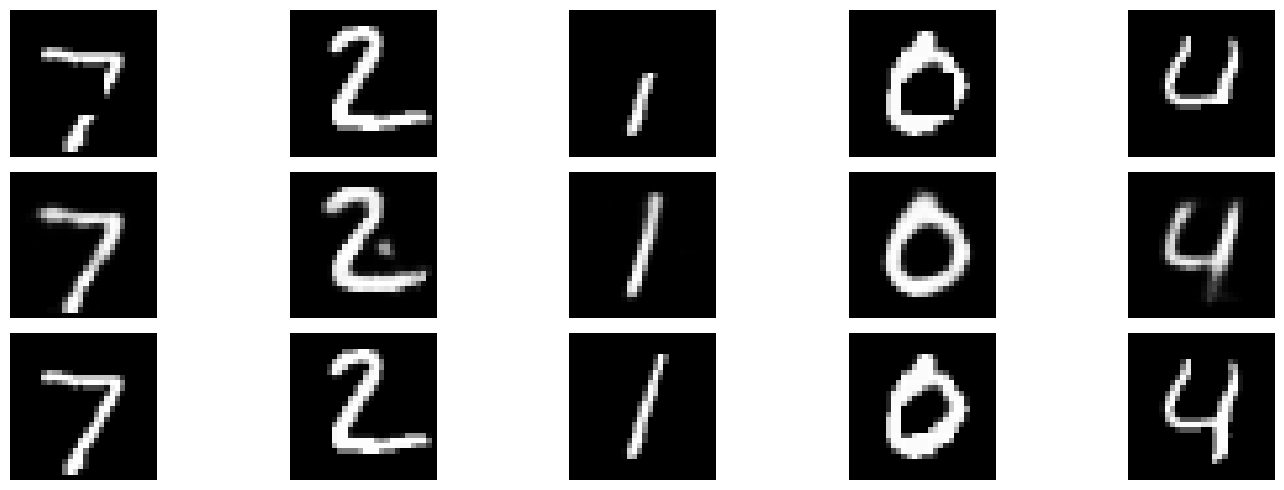

In [ ]:
n = 5
preds = test_pred[:n]
plt.figure(figsize=(15, 5))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(X_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(3, n, n+i+1)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(3, n, 2*n+i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()